In [1]:
import pandas as pd
import numpy as np

# HTTP requests and JSON processing
import requests
import json

# File and operating system utilities
import os
import shutil

# Install rapidfuzz if not already installed
!pip install rapidfuzz

# String similarity
from rapidfuzz import fuzz

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# Handling imbalanced data
from imblearn.over_sampling import SMOTE

# Model saving
import joblib

# Display settings
pd.set_option("display.max_columns", None)

print("All required libraries imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 61.4 MB/s eta 0:00:00
All required libraries imported successfully.



# Step 2: Collect Real Malicious Packages (OpenSSF)
#
# Source:
# https://github.com/ossf/malicious-packages
#
# The Open Source Security Foundation (OpenSSF) maintains
# a public repository of documented malicious software
# packages reported across multiple package ecosystems.
#
# In this research, real malicious Python package records
# are collected from the OpenSSF repository and used for
# validating the proposed machine learning model.


In [2]:
!git clone https://github.com/ossf/malicious-packages.git

Cloning into 'malicious-packages'...
remote: Enumerating objects: 1258402, done.
remote: Counting objects: 100% (4013/4013), done.
remote: Compressing objects: 100% (332/332), done.
remote: Total 1258402 (delta 3949), reused 3700 (delta 3676), pack-reused 1254389 (from 6)
Receiving objects: 100% (1258402/1258402), 285.08 MiB | 15.31 MiB/s, done.
Resolving deltas: 100% (624541/624541), done.
Updating files: 100% (232780/232780), done.


In [3]:
import os

pypi_files = []

for root, dirs, files in os.walk("malicious-packages/osv"):
    for file in files:
        if file.endswith(".json"):
            path = os.path.join(root, file)
            if "PyPI" in path or "pypi" in path:
                pypi_files.append(path)

print("Total PyPI advisory files:", len(pypi_files))

print("\nFirst 10 files:\n")

for file in pypi_files[:10]:
    print(file)

Total PyPI advisory files: 11578

First 10 files:

malicious-packages/osv/withdrawn/pypi/ranno/MAL-2026-4786.json
malicious-packages/osv/withdrawn/pypi/cdktn-provider-newrelic/MAL-2026-4825.json
malicious-packages/osv/withdrawn/pypi/heims/MAL-2026-4754.json
malicious-packages/osv/withdrawn/pypi/pywingui/MAL-2026-4821.json
malicious-packages/osv/withdrawn/pypi/indextts-cli/MAL-2026-4794.json
malicious-packages/osv/withdrawn/pypi/strawberry-graphql/MAL-2026-4771.json
malicious-packages/osv/withdrawn/pypi/qontract-reconcile/MAL-2026-4765.json
malicious-packages/osv/withdrawn/pypi/fastapi/MAL-2026-4750.json
malicious-packages/osv/withdrawn/pypi/aurapro-ui/MAL-2026-4742.json
malicious-packages/osv/withdrawn/pypi/nvidia-nat-semantic-kernel/MAL-2026-4760.json


In [4]:
import os
import json
import pandas as pd

malicious_packages = []

for file_path in pypi_files:

    try:
        with open(file_path, "r", encoding="utf-8") as file:
            data = json.load(file)

        package_name = data.get("affected", [{}])[0].get("package", {}).get("name")

        if package_name:
            malicious_packages.append(package_name)

    except Exception:
        continue

# Remove duplicates
malicious_packages = sorted(set(malicious_packages))

df_malicious = pd.DataFrame({
    "Package": malicious_packages,
    "Label": 1
})

print("Total Unique Malicious Packages:", len(df_malicious))

df_malicious.head()

Total Unique Malicious Packages: 11578


,Package,Label
0,0-8,1
1,0x000testqwe,1
2,123bla,1
3,1337test,1
4,18923aa,1


In [5]:
df_malicious.to_csv(
    "real_malicious_packages.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


In [6]:
print(df_malicious.sample(10))

               Package  Label
10291   tploadpingrand      1
1339     cryptocmopare      1
8132            rtpoc1      1
698     bussardweg4av3      1
9385      spl-token-py      1
7452     python-inance      1
11363         weedydev      1
11038      utf-cleaner      1
4247   libintelurllgtb      1
2797        etherreeum      1


In [7]:
import os

print("Repository downloaded successfully.")

print("\nTop-level folders:\n")

for item in os.listdir("malicious-packages"):
    print(item)

Repository downloaded successfully.

Top-level folders:

osv
CONTRIBUTING.md
CODE_OF_CONDUCT.md
.gitignore
LICENSE
README.md
Makefile
docs
SECURITY.md
.github
site
.golangci.yml
.git
go.sum
go.mod
internal
cmd
config


In [8]:
import requests

package = "requests"

url = f"https://pypi.org/pypi/{package}/json"

response = requests.get(url)

data = response.json()

print("Package:", data["info"]["name"])
print("Version:", data["info"]["version"])
print("Author:", data["info"]["author"])

Package: requests
Version: 2.34.2
Author: None


In [9]:
import requests
import pandas as pd

packages = packages = [
    "requests","numpy","pandas","scikit-learn","flask",
    "django","matplotlib","tensorflow","beautifulsoup4","pytest",
    "torch","keras","streamlit","fastapi","opencv-python",
    "plotly","sqlalchemy","jupyter","notebook","xgboost",
    "lightgbm","scipy","sympy","pillow","scrapy",
    "celery","boto3","pymongo","nltk","spacy",
    "transformers","sentencepiece","joblib","gunicorn","uvicorn",
    "dash","networkx","statsmodels","pyyaml","openpyxl",
    "lxml","aiohttp","tqdm","faker","cryptography",
    "pyarrow","geopy","folium","wordcloud","imbalanced-learn"
]

data_list = []

for package in packages:
    try:
        url = f"https://pypi.org/pypi/{package}/json"
        response = requests.get(url)
        data = response.json()

        info = data["info"]

        data_list.append({
            "Package": info.get("name"),
            "Version": info.get("version"),
            "Author": info.get("author"),
            "Summary": info.get("summary")
        })

    except Exception as e:
        print(f"Error fetching {package}: {e}")

df = pd.DataFrame(data_list)

print(df)

df.to_csv("package_dataset.csv", index=False)

print("\nDataset saved successfully!")

             Package   Version  \
0           requests    2.34.2   
1              numpy     2.5.1   
2             pandas     3.0.5   
3       scikit-learn     1.9.0   
4              Flask     3.1.3   
5             Django     6.0.7   
6         matplotlib    3.11.1   
7         tensorflow    2.21.0   
8     beautifulsoup4    4.15.0   
9             pytest     9.1.1   
10             torch    2.13.0   
11             keras    3.15.0   
12         streamlit    1.60.0   
13           fastapi   0.140.0   
14     opencv-python  5.0.0.93   
15            plotly     6.9.0   
16        SQLAlchemy    2.0.51   
17           jupyter     1.1.1   
18          notebook     7.6.1   
19           xgboost     3.3.0   
20          lightgbm     4.7.0   
21             scipy    1.18.0   
22             sympy    1.14.0   
23            pillow    12.3.0   
24            Scrapy    2.17.0   
25            celery     5.6.3   
26             boto3   1.43.56   
27           pymongo    4.17.0   
28            

In [10]:
import pandas as pd

package_data = pd.DataFrame({

    "Package": [
        "requsets",
        "numppy",
        "pands",
        "djagno",
        "flsak",
        "tensorf1ow"
    ],

    "SimilarityScore": [
        87.50,
        90.91,
        90.91,
        83.33,
        80.00,
        90.00
    ],

    "AgeDays": [
        10,
        5,
        15,
        40,
        20,
        3
    ],

    "Downloads": [
        100,
        50,
        75,
        300,
        250,
        20
    ]
})

package_data

,Package,SimilarityScore,AgeDays,Downloads
0,requsets,87.50,10,100
1,numppy,90.91,5,50
2,pands,90.91,15,75
3,djagno,83.33,40,300
4,flsak,80.00,20,250
5,tensorf1ow,90.00,3,20


In [11]:
def calculate_risk(row):

    similarity_component = row["SimilarityScore"] * 0.4

    age_component = max(0, (30 - row["AgeDays"])) * 0.6

    download_component = max(0, (500 - row["Downloads"])) / 10

    risk_score = (
        similarity_component +
        age_component +
        download_component
    )

    return round(risk_score, 2)

package_data["RiskScore"] = package_data.apply(
    calculate_risk,
    axis=1
)

package_data = package_data.sort_values(
    by="RiskScore",
    ascending=False
)

package_data

,Package,SimilarityScore,AgeDays,Downloads,RiskScore
5,tensorf1ow,90.00,3,20,100.20
1,numppy,90.91,5,50,96.36
2,pands,90.91,15,75,87.86
0,requsets,87.50,10,100,87.00
4,flsak,80.00,20,250,63.00
3,djagno,83.33,40,300,53.33


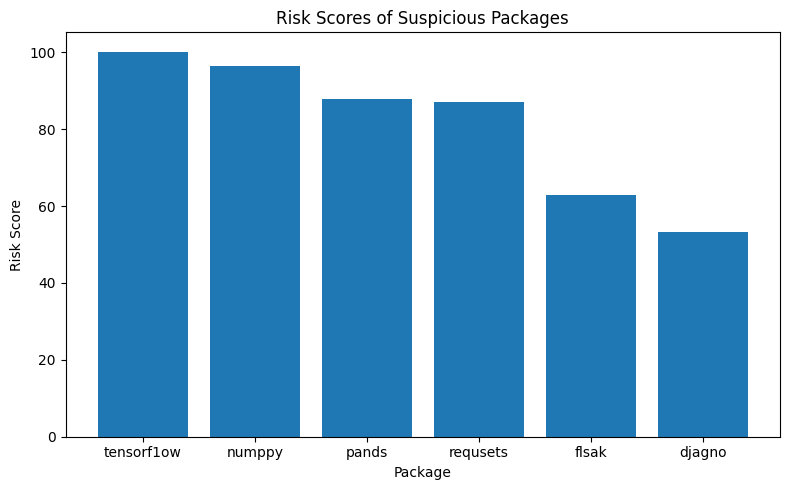

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    package_data["Package"],
    package_data["RiskScore"]
)

plt.xlabel("Package")
plt.ylabel("Risk Score")
plt.title("Risk Scores of Suspicious Packages")

plt.tight_layout()
plt.show()

In [13]:
import requests
import pandas as pd

packages = packages = [
    "requests","numpy","pandas","scikit-learn","flask",
    "django","matplotlib","tensorflow","beautifulsoup4","pytest",
    "torch","keras","streamlit","fastapi","opencv-python",
    "plotly","sqlalchemy","jupyter","notebook","xgboost",
    "lightgbm","scipy","sympy","pillow","scrapy",
    "celery","boto3","pymongo","nltk","spacy",
    "transformers","sentencepiece","joblib","gunicorn","uvicorn",
    "dash","networkx","statsmodels","pyyaml","openpyxl",
    "lxml","aiohttp","tqdm","faker","cryptography",
    "pyarrow","geopy","folium","wordcloud","imbalanced-learn"
]

rows = []

for package in packages:

    try:
        url = f"https://pypi.org/pypi/{package}/json"

        response = requests.get(url)

        data = response.json()

        info = data["info"]

        rows.append({
            "Package": info.get("name"),
            "Version": info.get("version"),
            "Author": info.get("author"),
            "Summary": info.get("summary"),
            "HomePage": info.get("home_page")
        })

    except Exception as e:
        print(package, e)

df_real = pd.DataFrame(rows)

print(df_real)

df_real.to_csv("real_packages.csv", index=False)

             Package   Version  \
0           requests    2.34.2   
1              numpy     2.5.1   
2             pandas     3.0.5   
3       scikit-learn     1.9.0   
4              Flask     3.1.3   
5             Django     6.0.7   
6         matplotlib    3.11.1   
7         tensorflow    2.21.0   
8     beautifulsoup4    4.15.0   
9             pytest     9.1.1   
10             torch    2.13.0   
11             keras    3.15.0   
12         streamlit    1.60.0   
13           fastapi   0.140.0   
14     opencv-python  5.0.0.93   
15            plotly     6.9.0   
16        SQLAlchemy    2.0.51   
17           jupyter     1.1.1   
18          notebook     7.6.1   
19           xgboost     3.3.0   
20          lightgbm     4.7.0   
21             scipy    1.18.0   
22             sympy    1.14.0   
23            pillow    12.3.0   
24            Scrapy    2.17.0   
25            celery     5.6.3   
26             boto3   1.43.56   
27           pymongo    4.17.0   
28            

In [14]:
risk_scores = []

df_real["NameLength"] = df_real["Package"].apply(lambda x: len(str(x)))
df_real["HasAuthor"] = df_real["Author"].apply(lambda x: 1 if pd.notna(x) else 0)
df_real["HasHomepage"] = df_real["HomePage"].apply(lambda x: 1 if pd.notna(x) else 0)

for _, row in df_real.iterrows():

    score = 0

    if row["NameLength"] < 6:
        score += 20

    if row["HasAuthor"] == 0:
        score += 30

    if row["HasHomepage"] == 0:
        score += 20

    risk_scores.append(score)

df_real["RiskScore"] = risk_scores

df_real = df_real.sort_values(
    by="RiskScore",
    ascending=False
)

print(
    df_real[
        [
            "Package",
            "RiskScore"
        ]
    ]
)

             Package  RiskScore
10             torch         70
4              Flask         70
11             keras         70
21             scipy         70
42              tqdm         70
0           requests         50
8     beautifulsoup4         50
12         streamlit         50
15            plotly         50
2             pandas         50
13           fastapi         50
33          gunicorn         50
24            Scrapy         50
23            pillow         50
18          notebook         50
19           xgboost         50
3       scikit-learn         50
5             Django         50
48         wordcloud         50
49  imbalanced-learn         50
45           pyarrow         50
46             geopy         50
36          networkx         50
41           aiohttp         50
34           uvicorn         50
20          lightgbm         50
31     sentencepiece         50
44      cryptography         50
32            joblib         50
1              numpy         40
37      

Large Package Dataset

In [15]:
import requests
import pandas as pd

popular_packages = [

    "requests","numpy","pandas","django","flask",
    "tensorflow","torch","scipy","matplotlib","pytest",

    "fastapi","seaborn","keras","opencv-python","pillow",
    "sqlalchemy","beautifulsoup4","streamlit","plotly","xgboost",

    "jupyter","notebook","pydantic","uvicorn","transformers",
    "nltk","spacy","sympy","networkx","statsmodels",

    "lightgbm","catboost","dash","bokeh","scrapy",
    "selenium","openpyxl","xlrd","pyarrow","dask",

    "pyspark","joblib","tqdm","faker","rich",
    "httpx","aiohttp","cryptography","paramiko","bcrypt",

    "pytest-cov","flake8","black","isort","mypy",
    "gunicorn","celery","redis","pymongo","psycopg2",

    "mysqlclient","sqlparse","jinja2","werkzeug","click",
    "typer","markdown","weasyprint","reportlab","pypdf",

    "pdfplumber","python-docx","python-pptx","odfpy","lxml",
    "xmltodict","yfinance","ccxt","ta","backtrader",

    "moviepy","imageio","albumentations","timm",
    "sentence-transformers","langchain","gradio",
    "datasets","evaluate","peft","accelerate",
    "faiss-cpu","folium","geopy","wordcloud",
    "imbalanced-learn","statsforecast","prophet"
]
rows = []

for package in popular_packages:

    try:
        url = f"https://pypi.org/pypi/{package}/json"

        response = requests.get(url)

        if response.status_code == 200:

            info = response.json()["info"]

            rows.append({
                "Package": info.get("name"),
                "Version": info.get("version"),
                "Summary": info.get("summary")
            })

    except:
        pass

df_packages = pd.DataFrame(rows)

print(df_packages)

print("Total Packages:", len(df_packages))

             Package Version  \
0           requests  2.34.2   
1              numpy   2.5.1   
2             pandas   3.0.5   
3             Django   6.0.7   
4              Flask   3.1.3   
..               ...     ...   
93             geopy   2.5.0   
94         wordcloud   1.9.6   
95  imbalanced-learn  0.14.2   
96     statsforecast   2.1.1   
97           prophet   1.3.0   

                                              Summary  
0                             Python HTTP for Humans.  
1   Fundamental package for array computing in Python  
2   Powerful data structures for data analysis, ti...  
3   A high-level Python web framework that encoura...  
4   A simple framework for building complex web ap...  
..                                                ...  
93                           Python Geocoding Toolbox  
94                      A little word cloud generator  
95  Toolbox for imbalanced dataset in machine lear...  
96  Time series forecasting suite using statistica...  

Generate Typosquatting Variants

In [16]:
import pandas as pd

generated_packages = []

for package in df_packages["Package"]:

    package = str(package).lower()

    variants = []

    # Variant 1 - Add character
    variants.append(package + "x")

    # Variant 2 - Add another character
    variants.append(package + "y")

    # Variant 3 - Remove last character
    if len(package) > 4:
        variants.append(package[:-1])

    # Variant 4 - Remove first character
    if len(package) > 4:
        variants.append(package[1:])

    # Variant 5 - Duplicate character
    if len(package) > 2:
        variants.append(
            package[:2] +
            package[2] +
            package[2:]
        )

    # Variant 6 - Replace second character with 1
    if len(package) > 3:
        variants.append(
            package.replace(
                package[1],
                "1",
                1
            )
        )

    # Variant 7 - Replace first character with 0
    if len(package) > 3:
        variants.append(
            "0" + package[1:]
        )

    # Variant 8 - Add pkg suffix
    variants.append(package + "pkg")

    # Variant 9 - Add lib suffix
    variants.append(package + "lib")

    # Variant 10 - Duplicate last character
    variants.append(package + package[-1])

    # Remove duplicates
    variants = list(set(variants))

    for variant in variants:

        generated_packages.append({
            "LegitimatePackage": package,
            "SuspiciousPackage": variant
        })

generated_df = pd.DataFrame(generated_packages)

print(generated_df.head())

print("\nTotal Suspicious Packages:",
      len(generated_df))

  LegitimatePackage SuspiciousPackage
0          requests         requestsx
1          requests           equests
2          requests       requestspkg
3          requests          r1quests
4          requests          0equests

Total Suspicious Packages: 935


High-Risk Packages

In [17]:
!pip install fuzzywuzzy

import pandas as pd
from fuzzywuzzy import fuzz

def calculate_similarity(row):
    return fuzz.ratio(row["LegitimatePackage"], row["SuspiciousPackage"])

similarity_df = generated_df.copy()
similarity_df["SimilarityScore"] = similarity_df.apply(calculate_similarity, axis=1)

high_risk = similarity_df[
    similarity_df["SimilarityScore"] >= 85
]

print(high_risk.head(30))

print(
    "\nTotal High Risk Packages:",
    len(high_risk)
)

   LegitimatePackage SuspiciousPackage  SimilarityScore
0           requests         requestsx               94
1           requests           equests               93
3           requests          r1quests               88
4           requests          0equests               88
6           requests         requestsy               94
7           requests           request               93
8           requests         requestss               94
9           requests         reqquests               94
11             numpy              nump               89
12             numpy            numpyy               91
13             numpy            numpyx               91
14             numpy              umpy               89
17             numpy            nummpy               91
20            pandas             andas               91
22            pandas             panda               91
24            pandas           pandass               92
25            pandas           pandasy          

/usr/local/lib/python3.12/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [18]:
high_risk["Label"] = 1

normal_packages = df_packages.copy()

normal_packages = normal_packages.rename(
    columns={
        "Package": "SuspiciousPackage"
    }
)

normal_packages["SimilarityScore"] = 0

normal_packages["Label"] = 0

normal_packages = normal_packages[
    [
        "SuspiciousPackage",
        "SimilarityScore",
        "Label"
    ]
]

high_risk_small = high_risk[
    [
        "SuspiciousPackage",
        "SimilarityScore"
    ]
].copy()

high_risk_small["Label"] = 1

final_dataset = pd.concat(
    [
        normal_packages,
        high_risk_small
    ],
    ignore_index=True
)

print(final_dataset.head())

print("\nDataset Shape:", final_dataset.shape)

  SuspiciousPackage  SimilarityScore  Label
0          requests                0      0
1             numpy                0      0
2            pandas                0      0
3            Django                0      0
4             Flask                0      0

Dataset Shape: (802, 3)


/tmp/ipykernel_786/3339550497.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_risk["Label"] = 1


In [19]:
final_dataset["NameLength"] = (
    final_dataset["SuspiciousPackage"]
    .str.len()
)

print(final_dataset.head())

print(final_dataset.shape)

  SuspiciousPackage  SimilarityScore  Label  NameLength
0          requests                0      0           8
1             numpy                0      0           5
2            pandas                0      0           6
3            Django                0      0           6
4             Flask                0      0           5
(802, 4)


In [20]:
def risk_category(score):

    if score >= 90:
        return "High"

    elif score >= 85:
        return "Medium"

    else:
        return "Low"

final_dataset["RiskCategory"] = (
    final_dataset["SimilarityScore"]
    .apply(risk_category)
)

print(
    final_dataset[
        [
            "SuspiciousPackage",
            "SimilarityScore",
            "RiskCategory"
        ]
    ].head(20)
)

   SuspiciousPackage  SimilarityScore RiskCategory
0           requests                0          Low
1              numpy                0          Low
2             pandas                0          Low
3             Django                0          Low
4              Flask                0          Low
5         tensorflow                0          Low
6              torch                0          Low
7              scipy                0          Low
8         matplotlib                0          Low
9             pytest                0          Low
10           fastapi                0          Low
11           seaborn                0          Low
12             keras                0          Low
13     opencv-python                0          Low
14            pillow                0          Low
15        SQLAlchemy                0          Low
16    beautifulsoup4                0          Low
17         streamlit                0          Low
18            plotly           

risk score

In [21]:
final_dataset["RiskScore"] = (
    final_dataset["SimilarityScore"] * 0.8
) + (
    final_dataset["NameLength"] * 0.2
)

print(
    final_dataset[
        [
            "SuspiciousPackage",
            "SimilarityScore",
            "NameLength",
            "RiskScore"
        ]
    ].head(20)
)

   SuspiciousPackage  SimilarityScore  NameLength  RiskScore
0           requests                0           8        1.6
1              numpy                0           5        1.0
2             pandas                0           6        1.2
3             Django                0           6        1.2
4              Flask                0           5        1.0
5         tensorflow                0          10        2.0
6              torch                0           5        1.0
7              scipy                0           5        1.0
8         matplotlib                0          10        2.0
9             pytest                0           6        1.2
10           fastapi                0           7        1.4
11           seaborn                0           7        1.4
12             keras                0           5        1.0
13     opencv-python                0          13        2.6
14            pillow                0           6        1.2
15        SQLAlchemy    

In [22]:
final_dataset.to_csv(
    "supply_chain_attack_dataset.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


Collect Real Metadata

In [23]:
import requests
import pandas as pd

rows = []

for package in popular_packages:

    try:

        url = f"https://pypi.org/pypi/{package}/json"

        response = requests.get(url)

        if response.status_code == 200:

            info = response.json()["info"]

            rows.append({

                "Package": info.get("name"),
                "Version": info.get("version"),
                "Summary": info.get("summary")

            })

    except:
        pass

df_100 = pd.DataFrame(rows)

print(df_100.head())

print("\nTotal Retrieved Packages:",
      len(df_100))

    Package Version                                            Summary
0  requests  2.34.2                            Python HTTP for Humans.
1     numpy   2.5.1  Fundamental package for array computing in Python
2    pandas   3.0.5  Powerful data structures for data analysis, ti...
3    Django   6.0.7  A high-level Python web framework that encoura...
4     Flask   3.1.3  A simple framework for building complex web ap...

Total Retrieved Packages: 98


Save

In [24]:
df_100.to_csv(
    "top100_packages.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


Generate Variants for All 96 Packages

In [25]:
import pandas as pd

generated_packages = []

for package in df_100["Package"]:

    package = str(package).lower()

    variants = []

    # Variant 1
    variants.append(package + "x")

    # Variant 2
    variants.append(package + "y")

    # Variant 3
    if len(package) > 4:
        variants.append(package[:-1])

    # Variant 4
    if len(package) > 4:
        variants.append(package[1:])

    # Variant 5
    if len(package) > 2:
        variants.append(
            package[:2] +
            package[2] +
            package[2:]
        )

    # Variant 6
    if len(package) > 3:
        variants.append(
            package.replace(
                package[1],
                "1",
                1
            )
        )

    # Variant 7
    if len(package) > 3:
        variants.append(
            "0" + package[1:]
        )

    # Variant 8
    variants.append(package + "pkg")

    # Variant 9
    variants.append(package + "lib")

    # Variant 10
    variants.append(package + package[-1])

    # Remove duplicates
    variants = list(set(variants))

    for variant in variants:

        generated_packages.append({
            "LegitimatePackage": package,
            "SuspiciousPackage": variant
        })

generated_df = pd.DataFrame(generated_packages)

print(generated_df.head())

print("\nTotal Suspicious Packages:",
      len(generated_df))

  LegitimatePackage SuspiciousPackage
0          requests         requestsx
1          requests           equests
2          requests       requestspkg
3          requests          r1quests
4          requests          0equests

Total Suspicious Packages: 935


Create High-Risk Dataset

In [26]:
high_risk = similarity_df[
    similarity_df["SimilarityScore"] >= 85
].copy()

print(high_risk.head())

print(
    "\nTotal High Risk Packages:",
    len(high_risk)
)

  LegitimatePackage SuspiciousPackage  SimilarityScore
0          requests         requestsx               94
1          requests           equests               93
3          requests          r1quests               88
4          requests          0equests               88
6          requests         requestsy               94

Total High Risk Packages: 704


In [27]:
normal_df = df_100.copy()

normal_df = normal_df.rename(
    columns={
        "Package": "Package"
    }
)

normal_df["SimilarityScore"] = 0
normal_df["Label"] = 0

normal_df = normal_df[
    [
        "Package",
        "SimilarityScore",
        "Label"
    ]
]

suspicious_df = high_risk.copy()

suspicious_df = suspicious_df.rename(
    columns={
        "SuspiciousPackage": "Package"
    }
)

suspicious_df["Label"] = 1

suspicious_df = suspicious_df[
    [
        "Package",
        "SimilarityScore",
        "Label"
    ]
]

final_dataset = pd.concat(
    [
        normal_df,
        suspicious_df
    ],
    ignore_index=True
)

print(final_dataset.head())

print("\nDataset Shape:",
      final_dataset.shape)

    Package  SimilarityScore  Label
0  requests                0      0
1     numpy                0      0
2    pandas                0      0
3    Django                0      0
4     Flask                0      0

Dataset Shape: (802, 3)


In [28]:
final_dataset["NameLength"] = (
    final_dataset["Package"]
    .str.len()
)

print(final_dataset.head())

    Package  SimilarityScore  Label  NameLength
0  requests                0      0           8
1     numpy                0      0           5
2    pandas                0      0           6
3    Django                0      0           6
4     Flask                0      0           5


In [29]:
final_dataset.to_csv(
    "final_detection_dataset.csv",
    index=False
)

print("Dataset Saved")

Dataset Saved


In [30]:
import pandas as pd

df = pd.read_csv("final_detection_dataset.csv")

print(df["Label"].value_counts())
print()
print(df["SimilarityScore"].describe())

Label
1    704
0     98
Name: count, dtype: int64

count    802.000000
mean      80.592269
std       30.206854
min        0.000000
25%       89.000000
50%       91.000000
75%       94.000000
max       98.000000
Name: SimilarityScore, dtype: float64


In [31]:
import pandas as pd

df = pd.read_csv("final_detection_dataset.csv")

print(df.head())
print("Total Packages:", len(df))

    Package  SimilarityScore  Label  NameLength
0  requests                0      0           8
1     numpy                0      0           5
2    pandas                0      0           6
3    Django                0      0           6
4     Flask                0      0           5
Total Packages: 802


Fetch PyPI Metadata

In [32]:
import requests
import pandas as pd
from datetime import datetime

enhanced_data = []

for _, row in df.iterrows():

    package = row["Package"]

    try:

        url = f"https://pypi.org/pypi/{package}/json"

        response = requests.get(url, timeout=10)

        if response.status_code == 200:

            data = response.json()

            info = data["info"]

            releases = data.get("releases", {})

            release_count = len(releases)

            summary = str(info.get("summary", ""))

            summary_length = len(summary)

            author = info.get("author", "Unknown")

            version = info.get("version", "Unknown")

            # Calculate package age

            release_dates = []

            for version_key in releases:

                files = releases[version_key]

                if len(files) > 0:

                    upload_time = files[0].get("upload_time")

                    if upload_time:

                        release_dates.append(upload_time)

            if len(release_dates) > 0:

                first_release = min(release_dates)

                package_age_days = (
                    datetime.now() -
                    datetime.strptime(
                        first_release,
                        "%Y-%m-%dT%H:%M:%S"
                    )
                ).days

            else:
                package_age_days = 0

        else:

            author = "Unknown"
            version = "Unknown"
            summary_length = 0
            release_count = 0
            package_age_days = 0

    except Exception:

        author = "Unknown"
        version = "Unknown"
        summary_length = 0
        release_count = 0
        package_age_days = 0

    enhanced_data.append({

        "Version": version,
        "Author": author,
        "SummaryLength": summary_length,
        "ReleaseCount": release_count,
        "PackageAgeDays": package_age_days

    })

Merge New Features

In [33]:
metadata_df = pd.DataFrame(enhanced_data)

enhanced_df = pd.concat(
    [df, metadata_df],
    axis=1
)

print(enhanced_df.head())

    Package  SimilarityScore  Label  NameLength Version  \
0  requests                0      0           8  2.34.2   
1     numpy                0      0           5   2.5.1   
2    pandas                0      0           6   3.0.5   
3    Django                0      0           6   6.0.7   
4     Flask                0      0           5   3.1.3   

                      Author  SummaryLength  ReleaseCount  PackageAgeDays  
0                       None             23           163            5641  
1  Travis E. Oliphant et al.             49           149            7177  
2                       None             71           117            6057  
3                       None             96           438            5914  
4                       None             57            64            5945  


Save Final Dataset

In [34]:
enhanced_df.to_csv(
    "enhanced_final_detection_dataset.csv",
    index=False
)

print("Enhanced dataset saved successfully!")

Enhanced dataset saved successfully!


In [35]:
print(enhanced_df.shape)
print(enhanced_df.columns.tolist())

(802, 9)
['Package', 'SimilarityScore', 'Label', 'NameLength', 'Version', 'Author', 'SummaryLength', 'ReleaseCount', 'PackageAgeDays']


In [36]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 802 entries, 0 to 801
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Package          802 non-null    object
 1   SimilarityScore  802 non-null    int64 
 2   Label            802 non-null    int64 
 3   NameLength       802 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 25.2+ KB
None


In [37]:
print(df.describe())

       SimilarityScore       Label  NameLength
count       802.000000  802.000000  802.000000
mean         80.592269    0.877805    8.522444
std          30.206854    0.327715    3.338217
min           0.000000    0.000000    2.000000
25%          89.000000    1.000000    6.000000
50%          91.000000    1.000000    8.000000
75%          94.000000    1.000000   10.000000
max          98.000000    1.000000   24.000000


In [38]:
print(df.isnull().sum())

Package            0
SimilarityScore    0
Label              0
NameLength         0
dtype: int64


In [39]:
print(df.duplicated().sum())

0


PHASE 3 – EXPLORATORY DATA ANALYSIS

Label Distribution

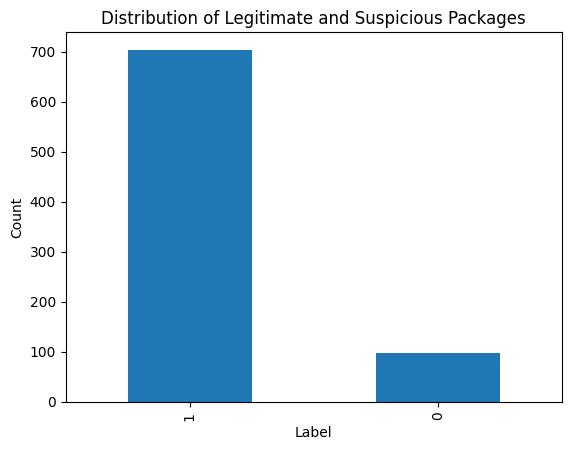

In [40]:
import matplotlib.pyplot as plt

df["Label"].value_counts().plot(kind="bar")

plt.title("Distribution of Legitimate and Suspicious Packages")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

Similarity Score Distribution

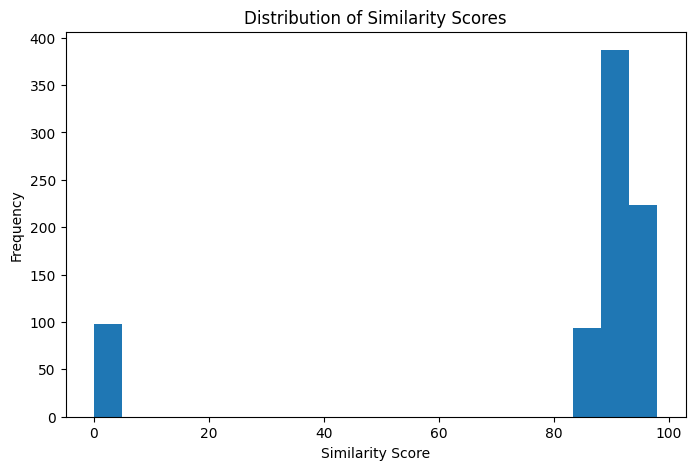

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("final_detection_dataset.csv")

plt.figure(figsize=(8,5))

plt.hist(df["SimilarityScore"], bins=20)

plt.title("Distribution of Similarity Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")

plt.show()

Summary Length Distribution

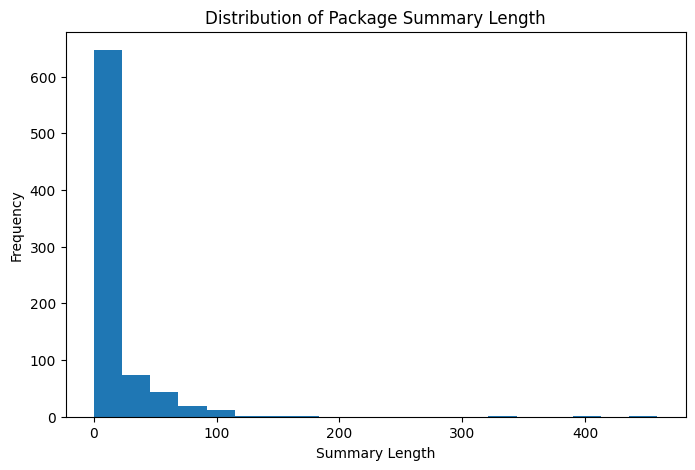

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("enhanced_final_detection_dataset.csv")

plt.figure(figsize=(8,5))

plt.hist(df["SummaryLength"], bins=20)

plt.title("Distribution of Package Summary Length")
plt.xlabel("Summary Length")
plt.ylabel("Frequency")

plt.show()

Correlation Analysis

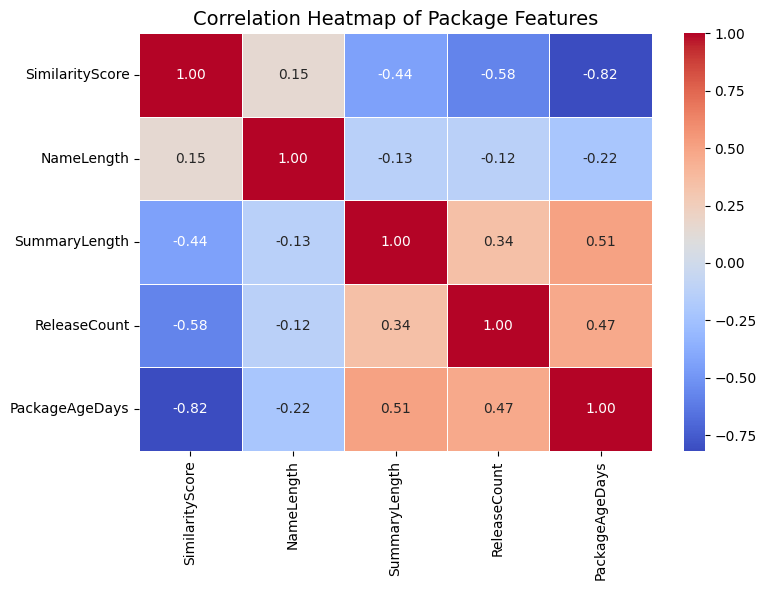

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("enhanced_final_detection_dataset.csv")

# Select numerical features
numeric_features = [
    "SimilarityScore",
    "NameLength",
    "SummaryLength",
    "ReleaseCount",
    "PackageAgeDays"
]

# Correlation matrix
corr_matrix = df[numeric_features].corr()

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Package Features",
    fontsize=14
)

plt.tight_layout()
plt.show()

Data Pre-processing.

In [44]:
print(
    df.dtypes
)

Package            object
SimilarityScore     int64
Label               int64
NameLength          int64
Version            object
Author             object
SummaryLength       int64
ReleaseCount        int64
PackageAgeDays      int64
dtype: object


In [45]:
features = [
    "SimilarityScore",
    "NameLength",
    "SummaryLength",
    "ReleaseCount",
    "PackageAgeDays"
]

X = df[features]

y = df["Label"]

In [46]:
print(
    y.value_counts()
)

Label
1    704
0     98
Name: count, dtype: int64


Train-Test Split

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

print("\nTraining Labels:")
print(y_train.value_counts())

print("\nTesting Labels:")
print(y_test.value_counts())

(641, 5)
(161, 5)

Training Labels:
Label
1    563
0     78
Name: count, dtype: int64

Testing Labels:
Label
1    141
0     20
Name: count, dtype: int64


In [48]:
print(X_train.shape)
print(X_test.shape)

(641, 5)
(161, 5)


Apply SMOTE

In [49]:
!pip install imbalanced-learn

In [50]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_balanced.value_counts())

Before SMOTE:
Label
1    563
0     78
Name: count, dtype: int64

After SMOTE:
Label
1    563
0    563
Name: count, dtype: int64


In [51]:
print(X_train_balanced.shape)

(1126, 5)


Feature Scaling


In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_balanced
)

X_test_scaled = scaler.transform(
    X_test
)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1126, 5)
(161, 5)


Model 1: Logistic Regression

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

lr_model = LogisticRegression(
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train_balanced
)

lr_pred = lr_model.predict(
    X_test_scaled
)

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1 Score:",
      f1_score(y_test, lr_pred))

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        lr_pred
    )
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00       141

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



Confusion Matrix

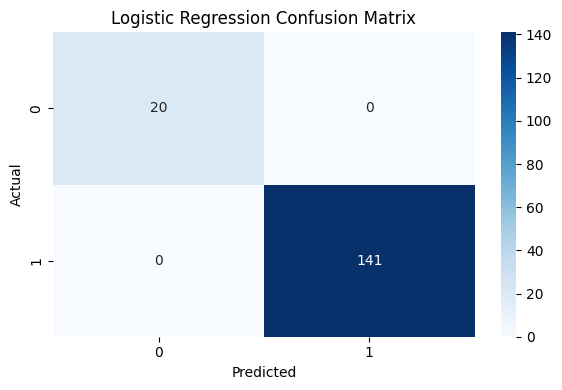

In [54]:
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

# Create the 'plots' directory if it doesn't exist
os.makedirs("plots", exist_ok=True)

plt.savefig(
    "plots/lr_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Decision Tree

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train_balanced,
    y_train_balanced
)

dt_pred = dt_model.predict(
    X_test
)

In [56]:
print(type(dt_model))

print("\nDecision Tree Depth:")
print(dt_model.get_depth())

print("\nNumber of Leaves:")
print(dt_model.get_n_leaves())

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

<class 'sklearn.tree._classes.DecisionTreeClassifier'>

Decision Tree Depth:
1

Number of Leaves:
2

Confusion Matrix:
[[ 20   0]
 [  0 141]]


In [57]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train_balanced,
    y_train_balanced
)

dt_pred = dt_model.predict(
    X_test
)

print("Accuracy:",
      accuracy_score(y_test, dt_pred))

print("Precision:",
      precision_score(y_test, dt_pred))

print("Recall:",
      recall_score(y_test, dt_pred))

print("F1 Score:",
      f1_score(y_test, dt_pred))

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        dt_pred
    )
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00       141

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



In [58]:
print("First 20 Decision Tree Predictions:")
print(dt_pred[:20])

First 20 Decision Tree Predictions:
[1 1 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1]


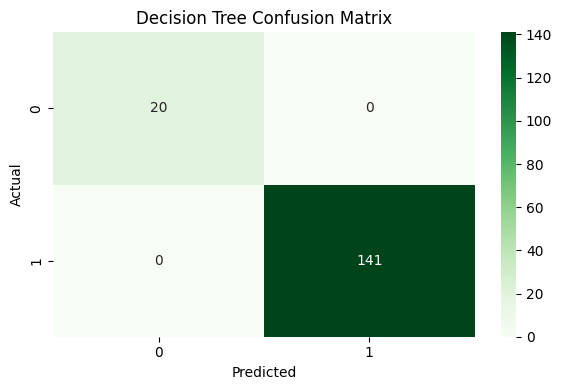

In [59]:
cm = confusion_matrix(
    y_test,
    dt_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "plots/dt_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Random Forest

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_balanced,
    y_train_balanced
)

rf_pred = rf_model.predict(
    X_test
)

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Precision:",
      precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1 Score:",
      f1_score(y_test, rf_pred))

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        rf_pred
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        rf_pred
    )
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00       141

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161


Confusion Matrix:
[[ 20   0]
 [  0 141]]


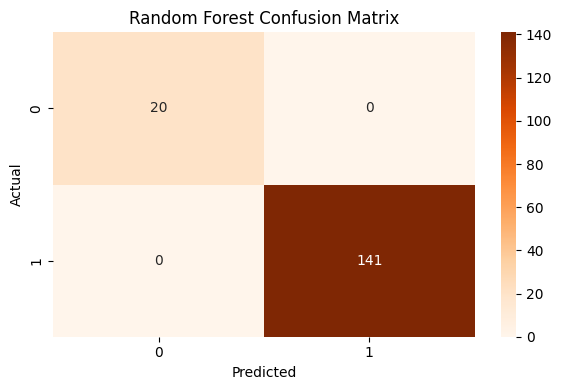

In [61]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "plots/rf_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Feature Importance Analysis

           Feature  Importance
0  SimilarityScore    0.445232
3     ReleaseCount    0.299559
4   PackageAgeDays    0.194627
2    SummaryLength    0.059327
1       NameLength    0.001254


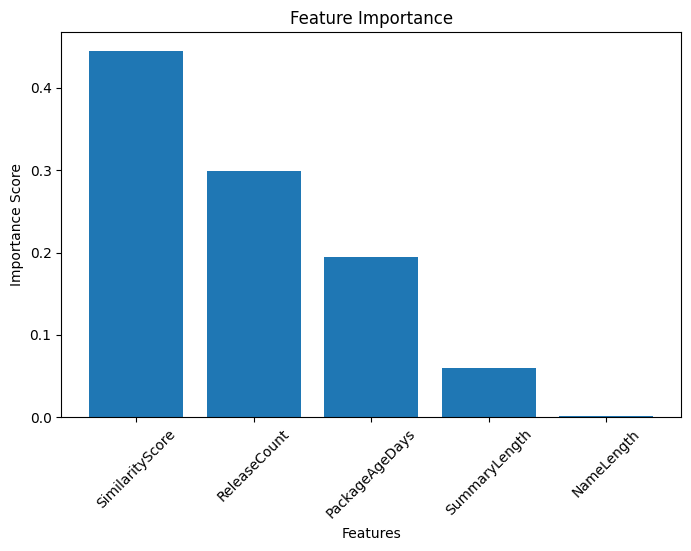

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(8,5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.show()

Model Comparison Plot

In [63]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

# Round values for presentation
results = results.round(4)

print(results)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression       1.0        1.0     1.0       1.0
1        Decision Tree       1.0        1.0     1.0       1.0
2        Random Forest       1.0        1.0     1.0       1.0


Accuracy Comparison

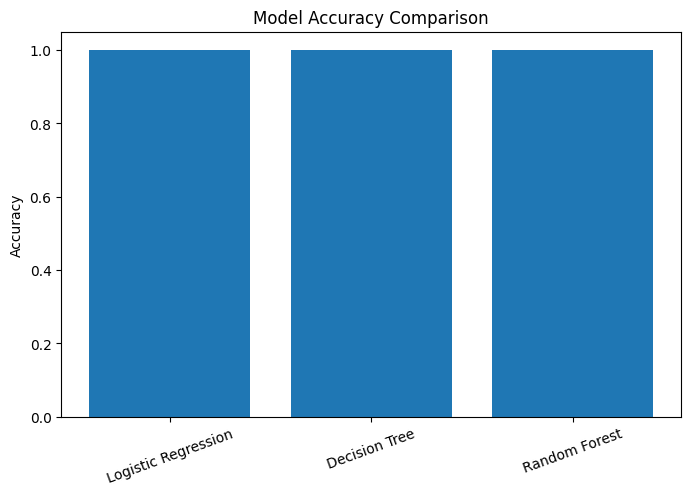

In [64]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

ROC Curve Analysis

Logistic Regression

In [65]:
lr_probs = lr_model.predict_proba(
    X_test_scaled
)[:,1]

Decision Tree

In [66]:
dt_probs = dt_model.predict_proba(
    X_test
)[:,1]

Random Forest

In [67]:
rf_probs = rf_model.predict_proba(
    X_test
)[:,1]

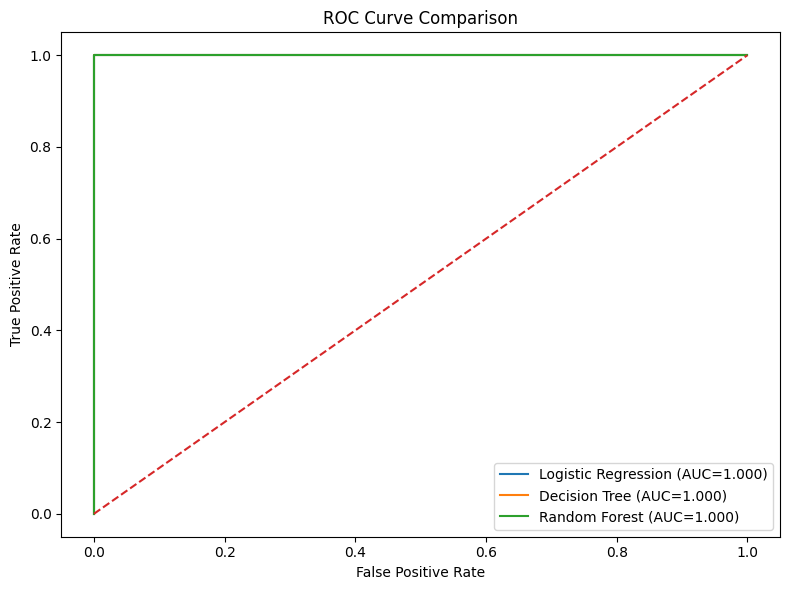

In [68]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC for Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_auc = auc(lr_fpr, lr_tpr)

# Calculate ROC curve and AUC for Decision Tree
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
dt_auc = auc(dt_fpr, dt_tpr)

# Calculate ROC curve and AUC for Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={lr_auc:.3f})"
)

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC={dt_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={rf_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(
    "plots/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Save Best Model

In [69]:
import joblib

joblib.dump(
    dt_model,
    "best_supply_chain_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [70]:
import os

os.makedirs("plots", exist_ok=True)
os.makedirs("assets", exist_ok=True)

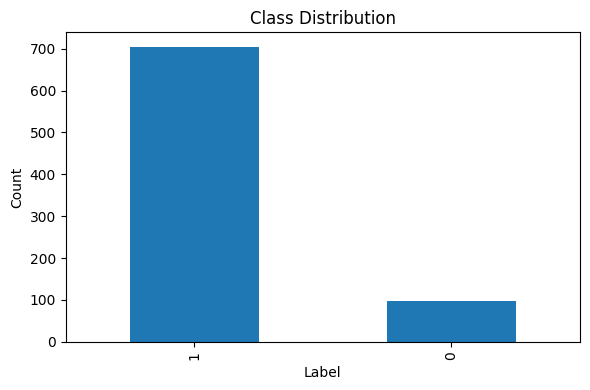

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df["Label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "plots/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

import seaborn as sns

numeric_features = [
    "SimilarityScore",
    "NameLength",
    "SummaryLength",
    "ReleaseCount",
    "PackageAgeDays"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "plots/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

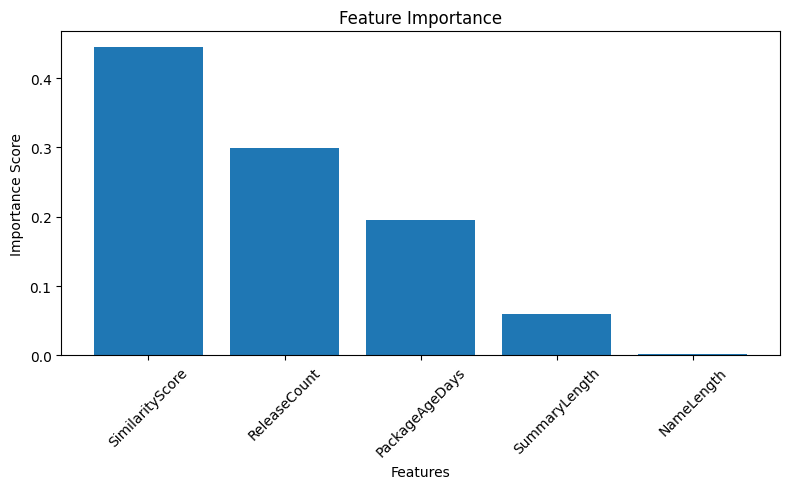

In [72]:
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

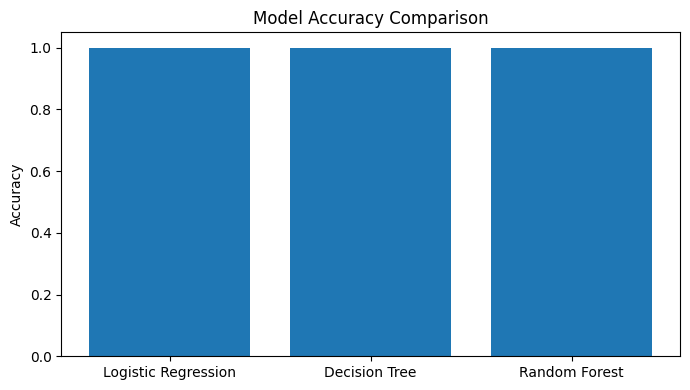

In [73]:
import pandas as pd

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        1.000,
        1.000,
        1.000
    ]
})

plt.figure(figsize=(7,4))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.tight_layout()

plt.savefig(
    "plots/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

External Validation Using OpenSSF Dataset

In [74]:
validation_df = df_malicious.sample(
    n=100,
    random_state=42
)

print(validation_df.head())

                  Package  Label
9308  solana-wallet-utils      1
6041             proofget      1
4421        libpepcandymc      1
5974   prof-tg-dooorto-qu      1
2342      esqosintvisapip      1


In [75]:
validation_df = df_malicious.sample(
    n=100,
    random_state=42
).reset_index(drop=True)

print(validation_df.head())
print("Packages Selected:", len(validation_df))

               Package  Label
0  solana-wallet-utils      1
1             proofget      1
2        libpepcandymc      1
3   prof-tg-dooorto-qu      1
4      esqosintvisapip      1
Packages Selected: 100


Fetch Metadata from PyPI

In [76]:
import requests
import pandas as pd
from datetime import datetime
from rapidfuzz import fuzz

# List of legitimate package names used during training
legitimate_packages = generated_df["LegitimatePackage"].unique().tolist()

validation_rows = []

for _, row in validation_df.iterrows():

    package = str(row["Package"]).lower()

    # -----------------------------
    # Calculate Similarity Score
    # -----------------------------
    similarity_score = max(
        fuzz.ratio(package, legit)
        for legit in legitimate_packages
    )

    # -----------------------------
    # Other Features
    # -----------------------------
    name_length = len(package)

    summary_length = 0
    release_count = 0
    package_age_days = 0
    version = "Unknown"
    author = "Unknown"

    try:

        url = f"https://pypi.org/pypi/{package}/json"

        response = requests.get(url, timeout=10)

        if response.status_code == 200:

            data = response.json()

            info = data["info"]

            version = info.get("version", "Unknown")
            author = info.get("author", "Unknown")

            summary = str(info.get("summary", ""))
            summary_length = len(summary)

            releases = data.get("releases", {})
            release_count = len(releases)

            release_dates = []

            for release in releases.values():

                if len(release) > 0:

                    upload_time = release[0].get("upload_time")

                    if upload_time:

                        release_dates.append(upload_time)

            if release_dates:

                first_release = min(release_dates)

                package_age_days = (
                    datetime.now()
                    - datetime.strptime(
                        first_release,
                        "%Y-%m-%dT%H:%M:%S"
                    )
                ).days

    except:
        pass

    validation_rows.append({

        "Package": package,
        "SimilarityScore": similarity_score,
        "NameLength": name_length,
        "Version": version,
        "Author": author,
        "SummaryLength": summary_length,
        "ReleaseCount": release_count,
        "PackageAgeDays": package_age_days,
        "Label": 1

    })

validation_metadata = pd.DataFrame(validation_rows)

print(validation_metadata.head())
print("\nValidation Dataset Shape:", validation_metadata.shape)

               Package  SimilarityScore  NameLength  Version   Author  \
0  solana-wallet-utils        42.424242          19  Unknown  Unknown   
1             proofget        66.666667           8  Unknown  Unknown   
2        libpepcandymc        42.105263          13  Unknown  Unknown   
3   prof-tg-dooorto-qu        34.482759          18  Unknown  Unknown   
4      esqosintvisapip        45.454545          15  Unknown  Unknown   

   SummaryLength  ReleaseCount  PackageAgeDays  Label  
0              0             0               0      1  
1              0             0               0      1  
2              0             0               0      1  
3              0             0               0      1  
4              0             0               0      1  

Validation Dataset Shape: (100, 9)


In [77]:
print(validation_metadata.shape)

print(validation_metadata.columns.tolist())

(100, 9)
['Package', 'SimilarityScore', 'NameLength', 'Version', 'Author', 'SummaryLength', 'ReleaseCount', 'PackageAgeDays', 'Label']


Create Validation Features

In [78]:
# Features used by the trained model

X_validation = validation_metadata[
    [
        "SimilarityScore",
        "NameLength",
        "SummaryLength",
        "ReleaseCount",
        "PackageAgeDays"
    ]
]

print(X_validation.head())

print("\nValidation Feature Shape:")
print(X_validation.shape)

   SimilarityScore  NameLength  SummaryLength  ReleaseCount  PackageAgeDays
0        42.424242          19              0             0               0
1        66.666667           8              0             0               0
2        42.105263          13              0             0               0
3        34.482759          18              0             0               0
4        45.454545          15              0             0               0

Validation Feature Shape:
(100, 5)


Load the Best Model

In [79]:
import joblib

model = joblib.load(
    "best_supply_chain_model.pkl"
)

Predict

In [80]:
predictions = model.predict(X_validation)

validation_metadata["Prediction"] = predictions

print(
    validation_metadata[
        [
            "Package",
            "Prediction"
        ]
    ].head(20)
)

                                       Package  Prediction
0                          solana-wallet-utils           0
1                                     proofget           1
2                                libpepcandymc           0
3                           prof-tg-dooorto-qu           0
4                              esqosintvisapip           1
5                                esqrehttpinfo           1
6                                     superget           1
7                                  py-lgtbping           1
8                                  matplottlib           1
9                    fastybird-triggers-module           1
10                                    ethreeum           1
11                                  libpingurl           0
12                    connections-api-requests           1
13                                   loadsuper           1
14                                 ctf-toolkit           1
15                               tpproofedpull          

External Validation Results

In [81]:
detected = (
    validation_metadata["Prediction"] == 1
).sum()

total = len(validation_metadata)

print("Packages Tested :", total)

print("Detected as Suspicious :", detected)

print(
    "Detection Rate :",
    round(detected / total * 100, 2),
    "%"
)

Packages Tested : 100
Detected as Suspicious : 78
Detection Rate : 78.0 %


In [82]:
print(X.columns.tolist())

['SimilarityScore', 'NameLength', 'SummaryLength', 'ReleaseCount', 'PackageAgeDays']
